In [1]:
import xgboost
import shap
from sklearn.datasets import fetch_california_housing

# 初始化JS环境（用于后续SHAP可视化）
shap.initjs()

# 加载替代数据集（加州房价数据）
california = fetch_california_housing()
X, y = california.data, california.target

# 初始化XGBoost回归模型并训练
model = xgboost.XGBRegressor().fit(X, y)

# 创建模型解释器，计算SHAP值
explainer = shap.Explainer(model)  # 绑定需要解释的XGBoost模型
shap_values = explainer(X)  # 计算每个样本中每个特征的SHAP值

D:\Anaconda3\Anaconda\envs\lisc\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8))

In [3]:
'''
提取第一个样本（索引为 0 的样本） 的 SHAP 值，包含该样本中每个特征对模型预测结果的具体影响：
每个特征对应一个 SHAP 值（正值表示该特征 “推高” 了预测结果，负值表示 “拉低” 了预测结果）；
这些值的总和加上模型的 “基准值”（所有样本的平均预测值），等于该样本的最终预测值。
'''
shap_values[0]

.values =
array([ 1.7081785 ,  0.09363674,  0.19277047,  0.01245449, -0.05390611,
        0.01571906, -0.39385185,  0.55515116], dtype=float32)

.base_values =
np.float32(2.0684865)

.data =
array([   8.3252    ,   41.        ,    6.98412698,    1.02380952,
        322.        ,    2.55555556,   37.88      , -122.23      ])

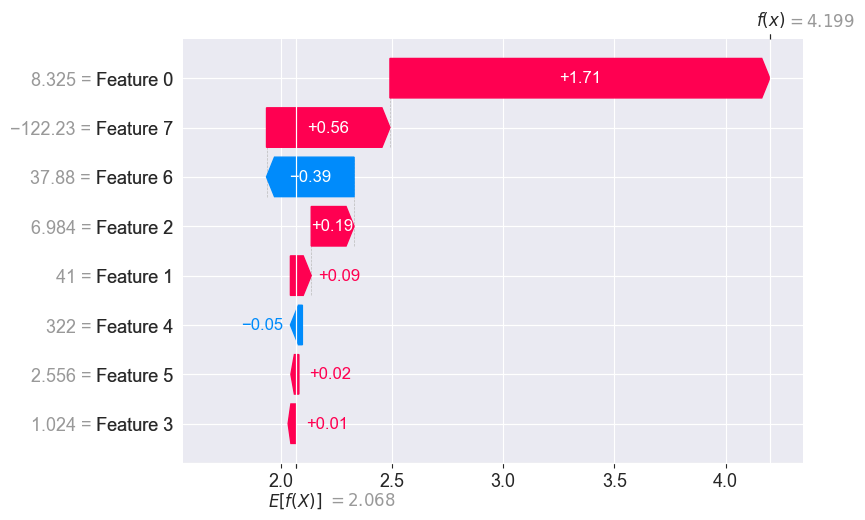

In [4]:
# 第0个样本的解释：以瀑布图形式可视化
# 局部解释单个样本预测逻辑
shap.plots.waterfall(shap_values[0])

横轴为SHAP值，纵轴是该样本各个特征的取值；
蓝色代表该特征对预测有负向影响（箭头朝左，SHAP值减少），红色代表该特征对预测有正向影响（箭头超右，SHAP值增加）；
最下方E[f(x)]示意SHAP基准值，也即该模型预测的均值，E是期望符号；
从下往上看，最底行代表4个不重要特征产生了0.04的负向影响，AGE=65.2产生了0.19的正向影响，
依此类推，最上行LSTAT=4.98产生了5.79的正向影响，最终得到样本的SHAP值是24.019（显示于右上角）；

In [5]:
# 第0个样本的解释：以力图形式可视化
shap.plots.force(shap_values[0])

In [9]:
import numpy as np

# 随机采样1000个样本的索引
sample_indices = np.random.choice(X.shape[0], size=1000, replace=False)

# numpy数组用 [] 索引
X_sample = X[sample_indices]  # 直接通过索引选取样本

# 对应的SHAP值也用同样的索引方式选取
shap_values_sample = shap_values[sample_indices]

# 可视化采样后的样本
shap.force_plot(explainer.expected_value,
                shap_values_sample.values,
                X_sample)

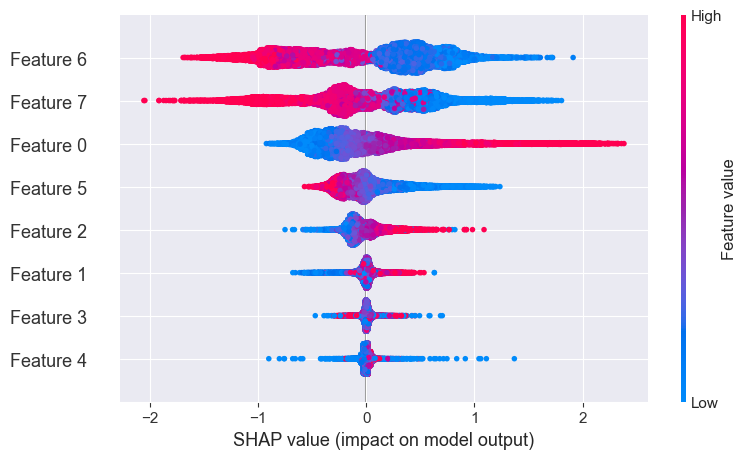

In [10]:
# 全局解释
shap.summary_plot(shap_values, X)

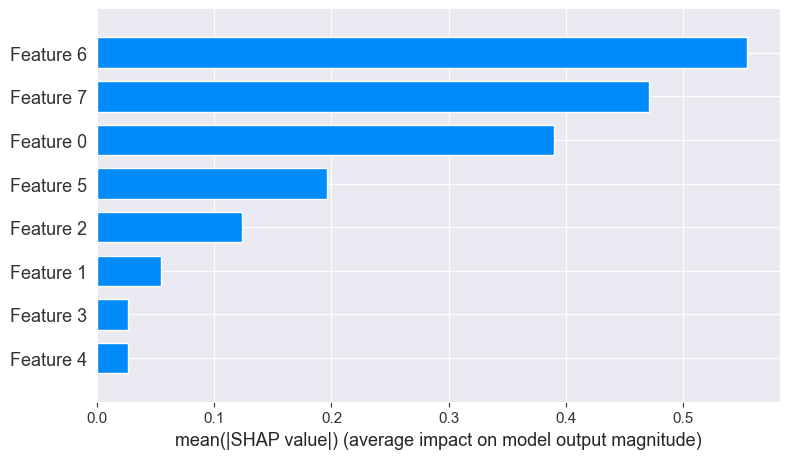

In [11]:
# 取每个特征的SHAP值的绝对值的平均值作为该特征的重要性
shap.summary_plot(shap_values, X, plot_type="bar")

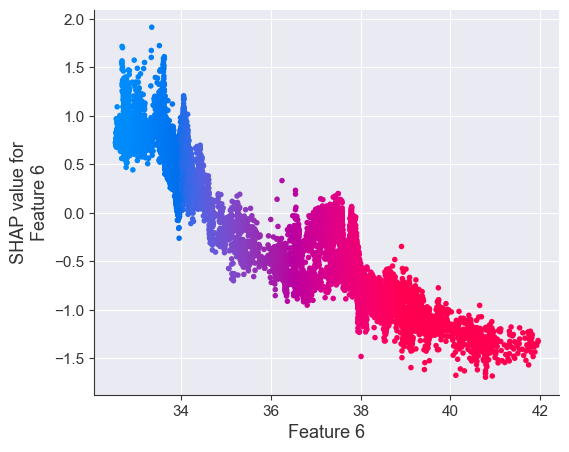

In [13]:
# 特征依赖
shap.dependence_plot("Feature 6", shap_values.values, X, interaction_index='Feature 6')

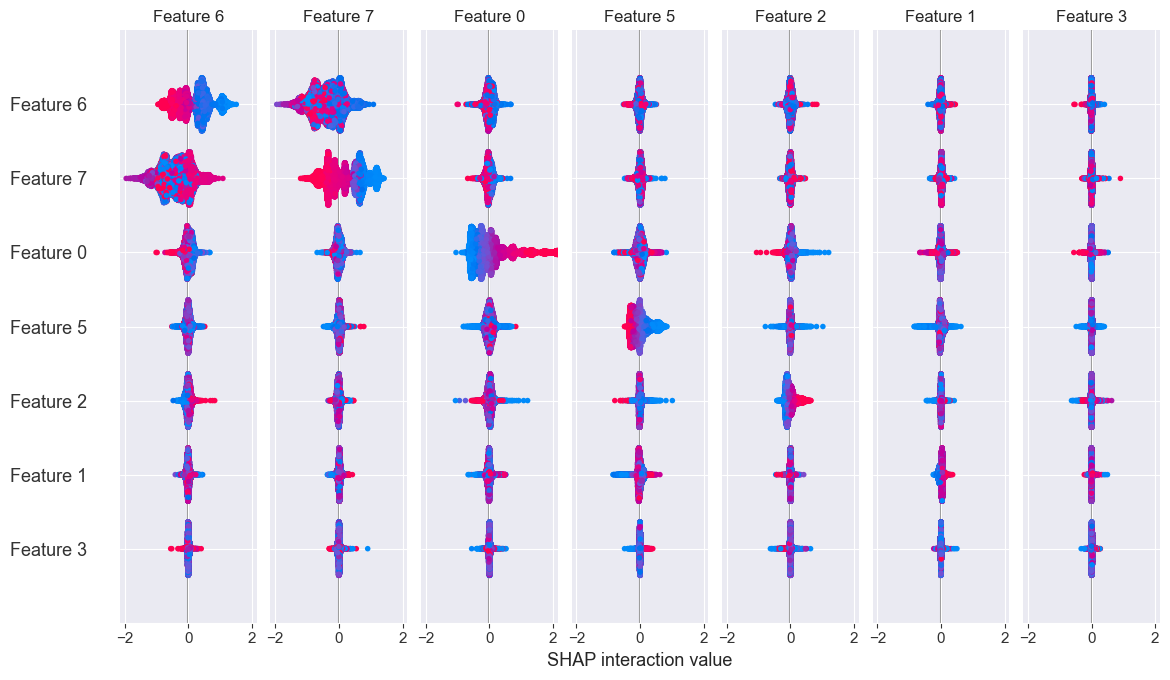

In [14]:
# 特征交互解释
shap_interaction_values = explainer.shap_interaction_values(X)
shap.summary_plot(shap_interaction_values, X)

In [15]:
print(shap_values.values[0][0])# 第0个样本的第0个特征的SHAP
print(shap_interaction_values[0][0].sum())# 第0个样本的第0个特征的交互SHAP之和

1.7081785
1.7081788


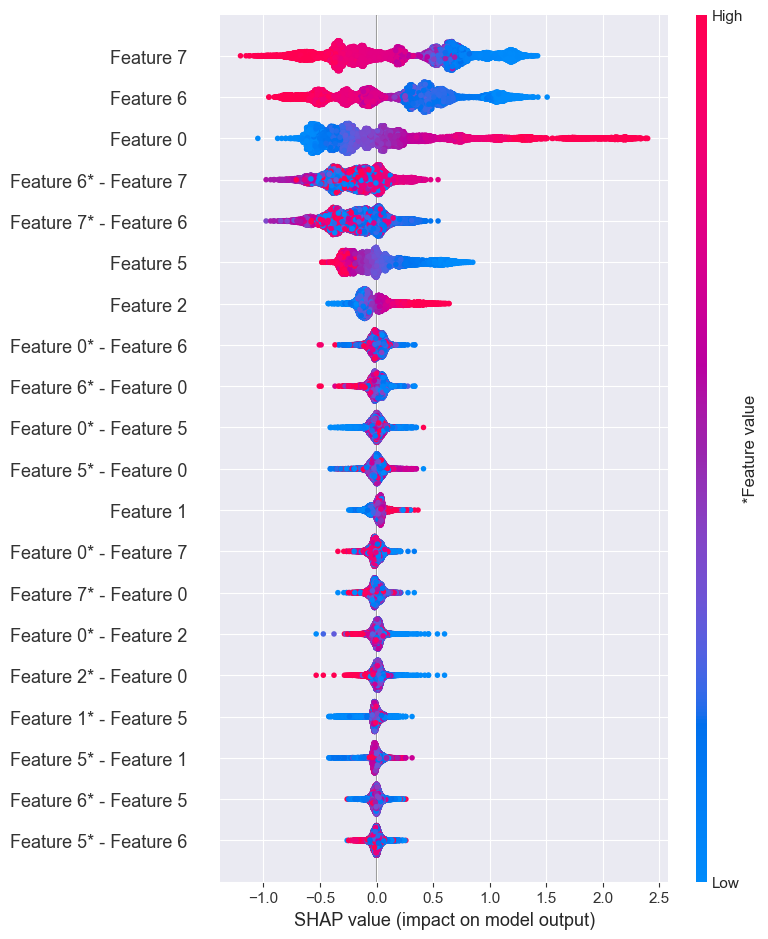

In [16]:
shap.summary_plot(shap_interaction_values, X,max_display=20,plot_type="compact_dot")
